# IBEE — Notebook 02: Preprocessing & Feature Engineering

**Input:** `data/processed/simulated_dataset.csv`  
**Output:** `data/processed/features.csv`

## Steps
1. Load & sanity-check  
2. Data cleaning  
3. Temporal features  
4. Rolling window statistics (per device)  
5. Domain features (beekeeping knowledge)  
6. Class balance check  
7. Correlation analysis  
8. Export feature matrix

In [1]:
import warnings, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,
    'axes.spines.top':False,'axes.spines.right':False,
    'axes.grid':True,'grid.alpha':0.3,
    'figure.dpi':130,'savefig.dpi':150,'savefig.bbox':'tight',
})
DATA_DIR    = Path('../data/processed')
REPORTS_DIR = Path('../reports/figures')
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
STATE_COLORS = {
    'normal':'#2a9d8f','swarming_risk':'#e9c46a',
    'robbing':'#e76f51','winter_cluster':'#457b9d','empty':'#adb5bd',
}
print('Ready.')

Ready.


## 1. Load & sanity-check

In [2]:
df = pd.read_csv(DATA_DIR / 'simulated_dataset.csv', parse_dates=['ts'])
df = df.sort_values(['device_id','ts']).reset_index(drop=True)
print(f'Shape      : {df.shape}')
print(f'Date range : {df.ts.min()} → {df.ts.max()}')
print(f'Devices    : {df.device_id.nunique()}')
print(f'States     : {sorted(df.hive_state.unique())}')
print(f'Missing    : {df.isnull().sum().sum()}')
display(df.head(3))
display(df.describe().round(3))

Shape      : (350400, 11)
Date range : 2024-09-01 00:00:00+00:00 → 2025-08-31 23:45:00+00:00
Devices    : 10
States     : ['normal', 'robbing', 'swarming_risk', 'winter_cluster']
Missing    : 0


,ts,device_id,temperature_c,humidity_pct,sound_level,door_open,weight_kg,battery_v,gps_lat,gps_lng,hive_state
0,2024-09-01 00:00:00+00:00,70b3d57ed0064a12,32.96,72.49,55,False,17.635,3.954,35.689509,-0.641700,normal
1,2024-09-01 00:15:00+00:00,70b3d57ed0064a12,31.17,73.16,45,False,17.625,3.954,35.689504,-0.641696,normal
2,2024-09-01 00:30:00+00:00,70b3d57ed0064a12,37.94,61.76,40,False,17.642,3.953,35.689499,-0.641708,normal


,temperature_c,humidity_pct,sound_level,weight_kg,battery_v,gps_lat,gps_lng
count,350400.000,350400.000,350400.000,350400.000,350400.000,350400.000,350400.000
mean,33.637,63.480,49.141,16.420,3.215,35.692,-0.642
std,3.261,9.795,21.931,4.611,0.085,0.003,0.001
min,28.000,30.000,0.000,5.000,3.200,35.689,-0.644
25%,31.430,57.480,34.000,13.524,3.200,35.690,-0.642
50%,33.550,63.920,50.000,16.297,3.200,35.690,-0.642
75%,35.600,69.870,64.000,19.520,3.200,35.694,-0.641
max,50.000,98.000,100.000,28.134,3.954,35.698,-0.641


,hive_state,count,pct
0,normal,253942,72.5
1,robbing,8918,2.5
2,swarming_risk,35566,10.2
3,winter_cluster,51974,14.8


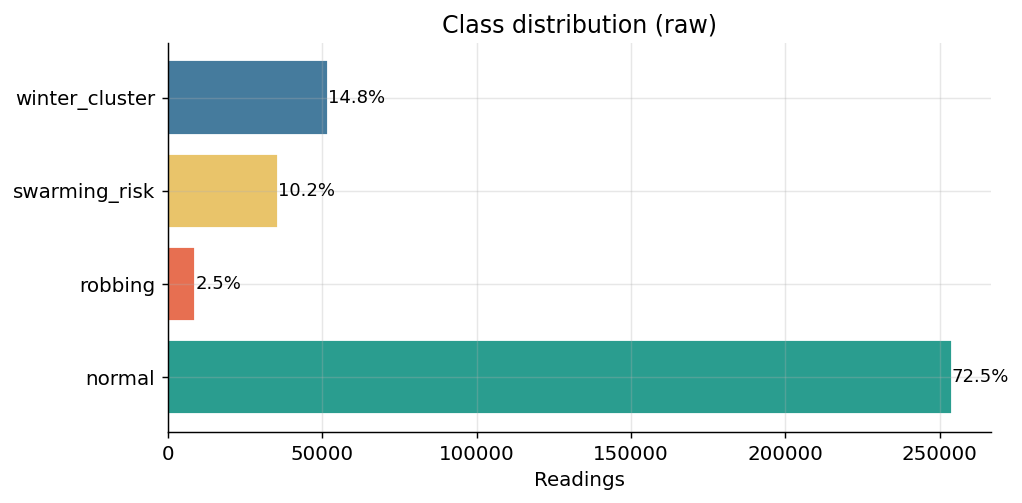

In [3]:
# Class distribution
dist = df.groupby('hive_state').size().reset_index(name='count')
dist['pct'] = (dist['count']/len(df)*100).round(1)
display(dist)

fig,ax = plt.subplots(figsize=(8,4))
colors = [STATE_COLORS.get(s,'#888') for s in dist['hive_state']]
ax.barh(dist['hive_state'],dist['count'],color=colors,edgecolor='white')
for i,(_,row) in enumerate(dist.iterrows()):
    ax.text(row['count']+50,i,f"{row['pct']}%",va='center',fontsize=10)
ax.set_xlabel('Readings'); ax.set_title('Class distribution (raw)')
plt.tight_layout()
plt.savefig(REPORTS_DIR/'class_distribution_raw.png')
plt.show()

## 2. Data cleaning

In [4]:
BOUNDS = {
    'temperature_c':(25.0,52.0),
    'humidity_pct' :(20.0,99.0),
    'sound_level'  :(0,100),
    'weight_kg'    :(3.0,45.0),
    'battery_v'    :(3.0,4.2),
}
print('Clipping to physical bounds:')
for col,(lo,hi) in BOUNDS.items():
    n = ((df[col]<lo)|(df[col]>hi)).sum()
    df[col] = df[col].clip(lo,hi)
    print(f'  {col:<20}: {n} rows clipped to [{lo},{hi}]')
df['door_open']   = df['door_open'].astype(int)
df['sound_level'] = df['sound_level'].astype(int)
print('Done.')

Clipping to physical bounds:
  temperature_c       : 0 rows clipped to [25.0,52.0]
  humidity_pct        : 0 rows clipped to [20.0,99.0]
  sound_level         : 0 rows clipped to [0,100]
  weight_kg           : 0 rows clipped to [3.0,45.0]
  battery_v           : 0 rows clipped to [3.0,4.2]
Done.


## 3. Temporal features

In [5]:
df['hour']        = df['ts'].dt.hour
df['day_of_week'] = df['ts'].dt.dayofweek
df['month']       = df['ts'].dt.month
df['is_daytime']  = ((df['hour']>=7)&(df['hour']<=20)).astype(int)

# Cyclical encoding — avoids 23→0 discontinuity
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['month_sin'] = np.sin(2*np.pi*(df['month']-1)/12)
df['month_cos'] = np.cos(2*np.pi*(df['month']-1)/12)
print('Temporal features added.')

Temporal features added.


## 4. Rolling window statistics
Window = 4 readings = 1 hour (15-min sampling). Applied **per device**.

In [6]:
WINDOW = 4  # 4 × 15 min = 1 hour
ROLLING_SENSORS = ['temperature_c','humidity_pct','sound_level','weight_kg','door_open']

groups = []
for dev,grp in df.groupby('device_id',sort=False):
    grp = grp.sort_values('ts').copy()
    for col in ROLLING_SENSORS:
        rolled = grp[col].rolling(WINDOW, min_periods=1)
        grp[f'{col}_roll_mean'] = rolled.mean().round(4)
        grp[f'{col}_roll_std']  = rolled.std().fillna(0).round(4)
    groups.append(grp)

df = pd.concat(groups).sort_values(['device_id','ts']).reset_index(drop=True)
roll_cols = [c for c in df.columns if 'roll' in c]
print(f'{len(roll_cols)} rolling features added.')

10 rolling features added.


## 5. Domain features — beekeeping knowledge

In [7]:
groups2 = []
for dev,grp in df.groupby('device_id',sort=False):
    grp = grp.sort_values('ts').copy()

    # Weight delta — key swarming/robbing indicator (HOBOS-calibrated)
    grp['weight_delta_1h']  = grp['weight_kg'].diff(WINDOW).round(4)
    grp['weight_delta_15m'] = grp['weight_kg'].diff(1).round(4)

    # Sound volatility — high during robbing (chaotic sound)
    grp['sound_volatility'] = grp['sound_level_roll_std']

    # Door event rate
    grp['door_rate_1h'] = grp['door_open_roll_mean']

    # Temp × humidity — both high = swarming risk
    grp['temp_hum_product'] = (grp['temperature_c']*grp['humidity_pct']/100).round(3)

    # Temp deviation from rolling mean
    grp['temp_deviation'] = (grp['temperature_c']-grp['temperature_c_roll_mean']).round(4)

    # Battery rate of change
    grp['battery_delta'] = grp['battery_v'].diff(1).round(5)

    groups2.append(grp)

df = pd.concat(groups2).sort_values(['device_id','ts']).reset_index(drop=True)

DOMAIN_COLS = ['weight_delta_1h','weight_delta_15m','sound_volatility',
               'door_rate_1h','temp_hum_product','temp_deviation','battery_delta']
df[DOMAIN_COLS] = df[DOMAIN_COLS].fillna(0)

print(f'Domain features added ({len(DOMAIN_COLS)}):')
for col in DOMAIN_COLS:
    print(f'  {col:<25}: mean={df[col].mean():.4f}  std={df[col].std():.4f}')

Domain features added (7):
  weight_delta_1h          : mean=-0.0003  std=0.0580
  weight_delta_15m         : mean=-0.0001  std=0.0276
  sound_volatility         : mean=12.4498  std=6.1435
  door_rate_1h             : mean=0.0466  std=0.1247
  temp_hum_product         : mean=21.4693  std=4.4874
  temp_deviation           : mean=-0.0001  std=2.3053
  battery_delta            : mean=-0.0000  std=0.0001


## 6. Feature-target split & class balance

In [8]:
FEATURES = [
    # Raw sensors
    'temperature_c','humidity_pct','sound_level','door_open','weight_kg','battery_v',
    # Temporal
    'hour_sin','hour_cos','month_sin','month_cos','is_daytime','day_of_week',
    # Rolling stats
    'temperature_c_roll_mean','temperature_c_roll_std',
    'humidity_pct_roll_mean','humidity_pct_roll_std',
    'sound_level_roll_mean','sound_level_roll_std',
    'weight_kg_roll_mean','weight_kg_roll_std',
    'door_open_roll_mean',
    # Domain
    'weight_delta_1h','weight_delta_15m',
    'sound_volatility','door_rate_1h',
    'temp_hum_product','temp_deviation',
]
TARGET = 'hive_state'

X = df[FEATURES]
y = df[TARGET]

print(f'Feature matrix : {X.shape}')
print(f'Missing in X   : {X.isnull().sum().sum()}')

class_counts  = y.value_counts()
imbalance     = class_counts.max() / class_counts.min()
print(f'\nClass counts:')
print(class_counts.to_string())
print(f'\nImbalance ratio: {imbalance:.1f}x')
if imbalance > 5:
    print('→ Use class_weight="balanced" in classifier')

Feature matrix : (350400, 27)
Missing in X   : 0

Class counts:
hive_state
normal            253942
winter_cluster     51974
swarming_risk      35566
robbing             8918

Imbalance ratio: 28.5x
→ Use class_weight="balanced" in classifier


## 7. Correlation analysis

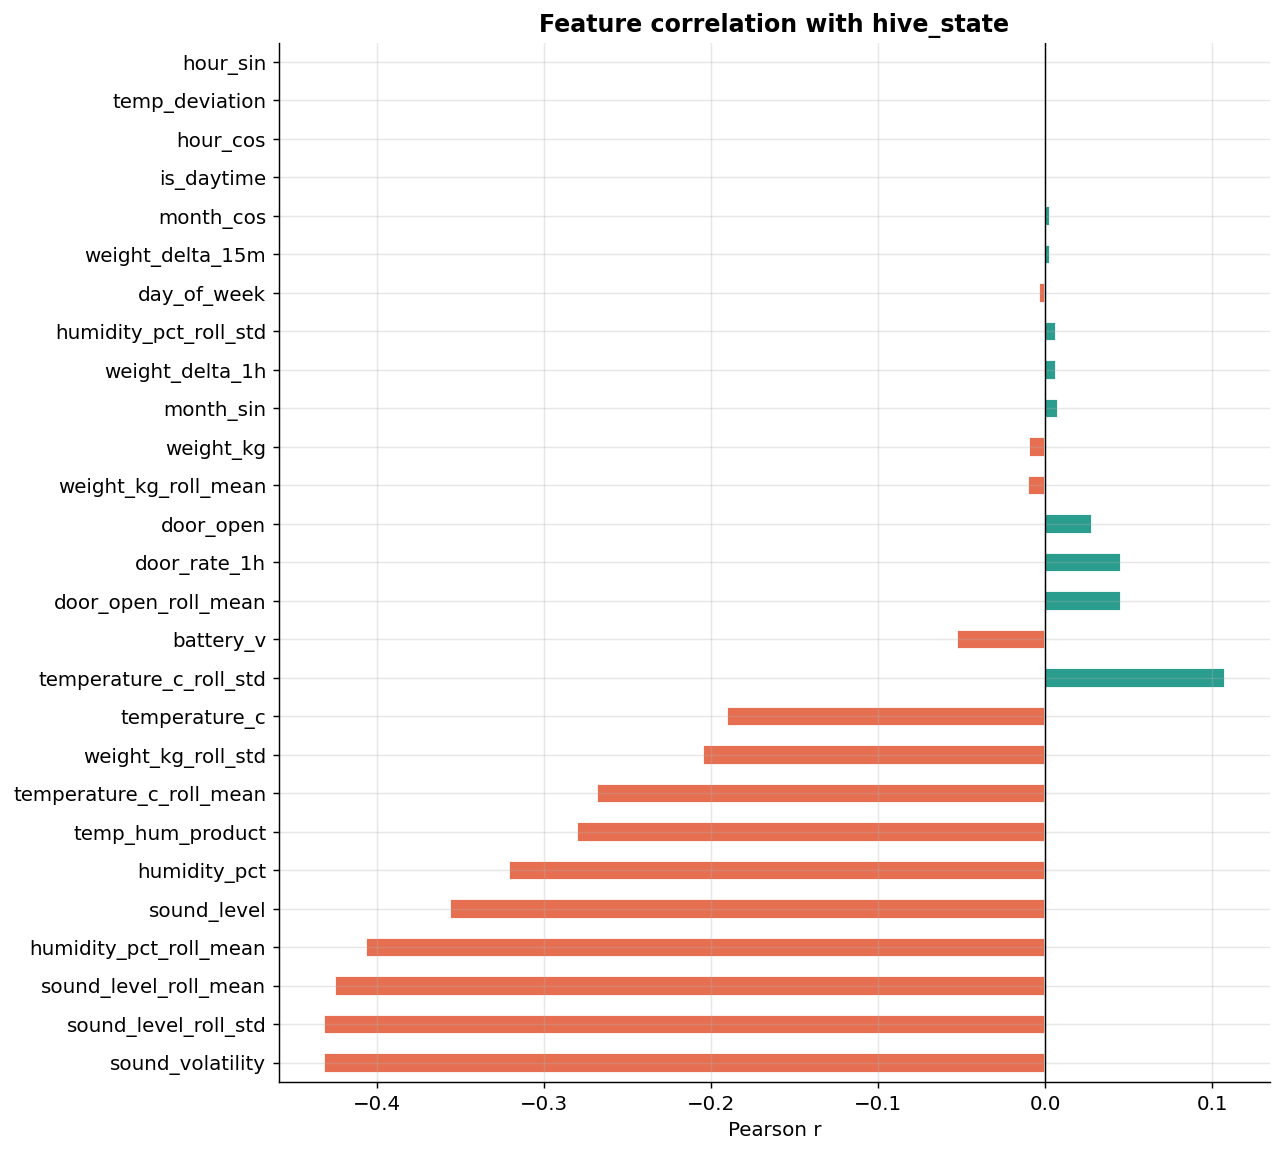

Top 10 features:
sound_volatility          -0.4316
sound_level_roll_std      -0.4316
sound_level_roll_mean     -0.4251
humidity_pct_roll_mean    -0.4066
sound_level               -0.3562
humidity_pct              -0.3209
temp_hum_product          -0.2799
temperature_c_roll_mean   -0.2683
weight_kg_roll_std        -0.2045
temperature_c             -0.1905


In [9]:
le = LabelEncoder()
df['hive_state_encoded'] = le.fit_transform(df['hive_state'])

target_corr = (
    df[FEATURES+['hive_state_encoded']]
    .corr()['hive_state_encoded']
    .drop('hive_state_encoded')
    .sort_values(key=abs,ascending=False)
)

fig,ax = plt.subplots(figsize=(10,9))
colors_bar = ['#e76f51' if v<0 else '#2a9d8f' for v in target_corr.values]
target_corr.plot.barh(ax=ax,color=colors_bar,edgecolor='white')
ax.set_title('Feature correlation with hive_state',fontweight='bold')
ax.set_xlabel('Pearson r')
ax.axvline(0,color='black',lw=0.8)
plt.tight_layout()
plt.savefig(REPORTS_DIR/'feature_target_correlation.png')
plt.show()

print('Top 10 features:')
print(target_corr.head(10).round(4).to_string())

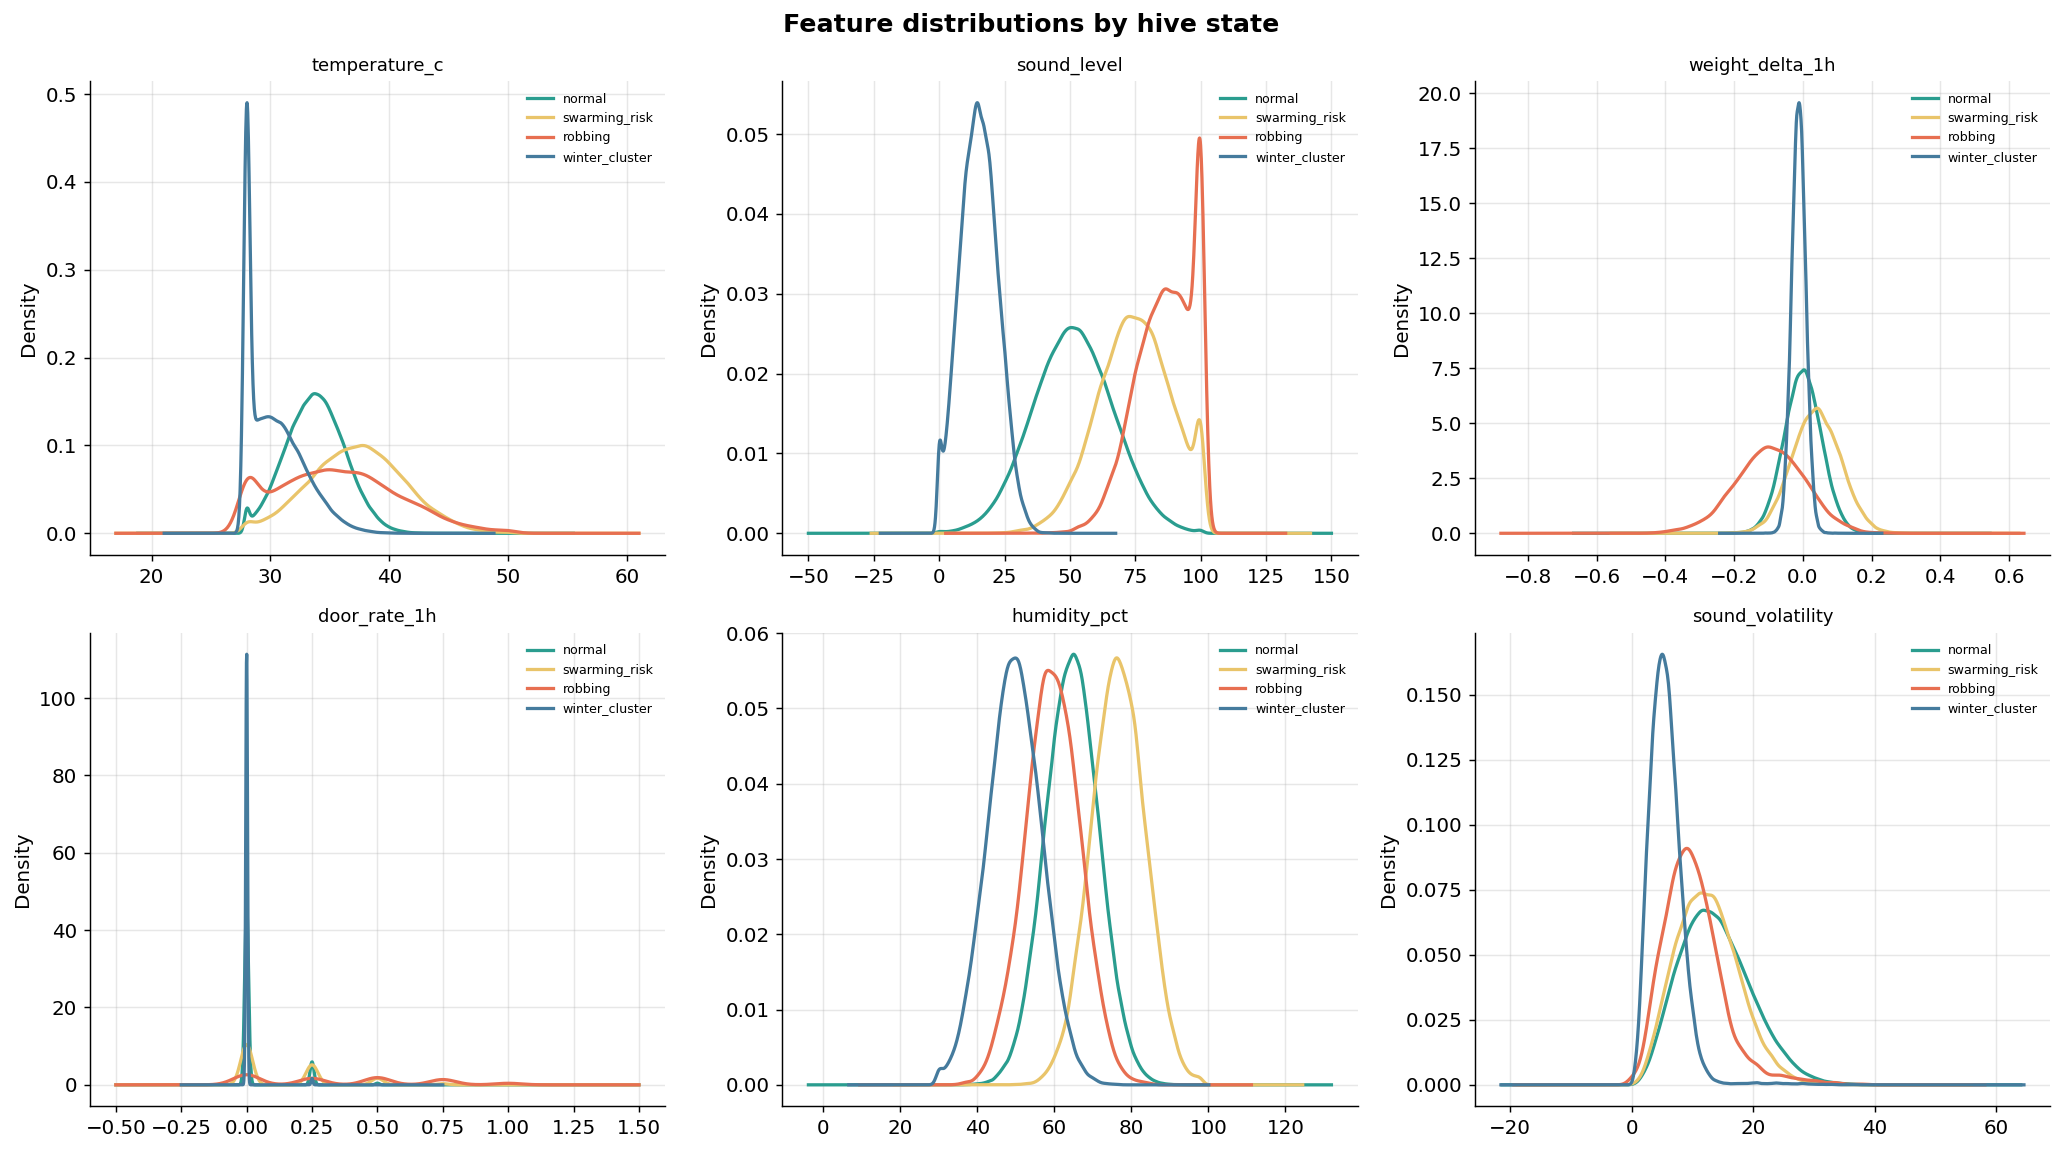

In [10]:
# Distribution of key features per state
KEY = ['temperature_c','sound_level','weight_delta_1h',
       'door_rate_1h','humidity_pct','sound_volatility']

fig,axes = plt.subplots(2,3,figsize=(16,9))
fig.suptitle('Feature distributions by hive state',fontsize=14,fontweight='bold')
for ax,feat in zip(axes.flat,KEY):
    for state,color in STATE_COLORS.items():
        sub = df[df['hive_state']==state][feat]
        if len(sub)<5: continue
        try: sub.plot.kde(ax=ax,label=state,color=color,lw=1.8)
        except: pass
    ax.set_title(feat,fontsize=10); ax.legend(fontsize=7,frameon=False)
plt.tight_layout()
plt.savefig(REPORTS_DIR/'feature_distributions_by_state.png')
plt.show()

## 8. Export feature matrix

In [11]:
META = ['ts','device_id','hive_state']
df_out = df[META+FEATURES].copy()
out_path = DATA_DIR/'features.csv'
df_out.to_csv(out_path,index=False)
print(f'✓ features.csv saved → {out_path}  shape={df_out.shape}')

meta = {
    'features'      : FEATURES,
    'target'        : TARGET,
    'n_features'    : len(FEATURES),
    'n_rows'        : len(df_out),
    'window_size'   : WINDOW,
    'window_minutes': WINDOW*15,
    'classes'       : sorted(df['hive_state'].unique().tolist()),
    'class_counts'  : df['hive_state'].value_counts().to_dict(),
}
(DATA_DIR/'features_meta.json').write_text(json.dumps(meta,indent=2))
print('✓ features_meta.json saved')
print()
print('Next: run notebooks/03_anomaly.ipynb')

✓ features.csv saved → ../data/processed/features.csv  shape=(350400, 30)
✓ features_meta.json saved

Next: run notebooks/03_anomaly.ipynb
